# Particle-Spray Streams with JAX

This notebook describes how to generate particle-spray tidal streams
(`fardal15spraydf` and `chen24spraydf`) and their smooth tracks with
[JAX](https://docs.jax.dev/), and how to differentiate them with respect to
the potential. See the [quick start](../getting_started/backends.ipynb) for
an introduction to galpy's backends and the [particle-spray
tutorial](streamspraydf.ipynb) for the models themselves.

Particle-spray models release particles from the progenitor at random times
with random offsets in position and velocity and integrate them forward. On
the backends, `sample` and the track-fitting method `streamTrack` are pure
functions of the progenitor's orbit, the potential, the progenitor's mass,
and a random key: the stripping times are drawn by inverse transformation of
uniform variates, the offsets are reparameterized normal variates, the
progenitor and the particles are integrated in the backend, and the track is
fit to the particles. The whole computation can be compiled with `jax.jit`
and differentiated with respect to every parameter. The derivatives are
*generative*: the particles are regenerated inside the derivative, so the
derivative of the track includes the response of every particle to the
parameter.

Forward mode (`jax.jvp`), which we use throughout because there is a single
parameter, uses diffrax's direct adjoint. We select it explicitly with
`integrate_kwargs={"adjoint": "direct"}` so that the examples run with every
version of JAX (recent versions select it by themselves; see the [orbits
notebook](../orbits/backends.ipynb)).

In [1]:
%matplotlib inline
import time

import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy

from galpy.backend import random as grandom
from galpy.df import fardal15spraydf
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.util import coords
from galpy.util.conversion import mass_in_msol, time_in_Gyr

# A GD-1-like stream: progenitor phase-space position, mass, disruption time
ic = [1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596]
mass = 2.0e4 / mass_in_msol(220.0, 8.0)
tdisrupt = 4.5 / time_in_Gyr(220.0, 8.0)
q0 = 0.9  # flattening of the logarithmic halo
key = grandom.key(1, backend="jax")
# A sky frame aligned with the progenitor's orbit: (phi1, phi2)
T = Orbit(ic).align_to_orbit()


def spray(q):
    """The stream in a logarithmic halo with flattening q"""
    return fardal15spraydf(
        mass,
        progenitor=Orbit(ic),
        pot=LogarithmicHaloPotential(normalize=1.0, q=q),
        tdisrupt=tdisrupt,
        tail="both",
        integrate_kwargs={"adjoint": "direct"},
    )

## The stream track

`streamTrack` samples particles and fits a smooth track through them,
parameterized by the time `tp` along the progenitor's orbit, together with
the $6\times6$ covariance of the particles around the track. With a JAX key,
the particles are drawn and integrated with JAX. For both tails, in the
stream-aligned frame `T`:

In [2]:
start = time.perf_counter()
track = spray(q0).streamTrack(n=2000, tail="both", key=key, custom_sky_transform=T)
print(f"{time.perf_counter() - start:.1f} s")
track.turn_physical_on()  # kpc, km/s, and deg, also for the covariance
print(
    type(track).__name__,
    track.leading.tp_grid()[[0, -1]],
    track.trailing.tp_grid()[[0, -1]],
)

30.1 s
StreamTrackPair [0.         1.44175538] [-1.38521912  0.        ]


The track has the same coordinate accessors as an `Orbit` (`x`, `vz`, `ra`,
`dist`, `vlos`, ..., and `phi1`, `phi2`, `pmphi1`, `pmphi2` in the custom
frame), and `cov(tp, basis=...)` gives the covariance in galactocentric,
sky, or custom-sky coordinates. For example, the width of the leading tail
in $\phi_2$, distance, and line-of-sight velocity halfway along it:

In [3]:
tp_mid = 0.5 * track.leading.tp_grid()[-1]
cov = track.leading.cov(
    tp_mid, basis="customsky"
)  # (phi1,phi2,dist,pmphi1,pmphi2,vlos)
print(f"phi1 = {track.leading.phi1(tp_mid):.2f} deg")
print(
    f"sigma(phi2) = {numpy.sqrt(cov[1, 1]):.3f} deg, "
    f"sigma(dist) = {numpy.sqrt(cov[2, 2]):.3f} kpc, "
    f"sigma(vlos) = {numpy.sqrt(cov[5, 5]):.2f} km/s"
)

phi1 = 129.21 deg
sigma(phi2) = 0.216 deg, sigma(dist) = 0.039 kpc, sigma(vlos) = 1.06 km/s


We plot the track and its $1\sigma$ spread from the covariance over the
particles that it was fit to (`track.particles`), on the sky and in
distance and line-of-sight velocity:

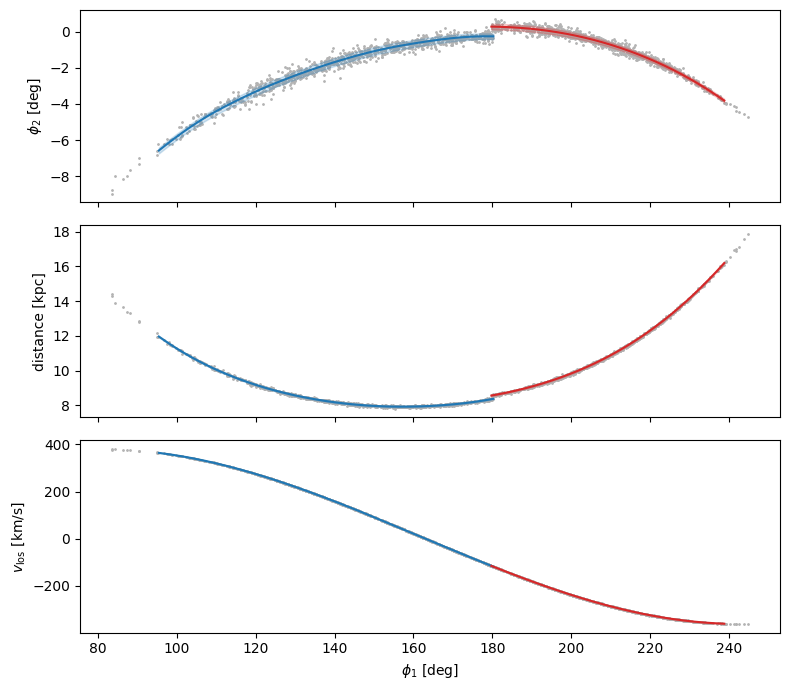

In [4]:
po = Orbit(track.particles.T, ro=8.0, vo=220.0)
p12 = coords.radec_to_custom(po.ra(), po.dec(), T=T, degree=True)
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for ax, d2, pval in zip(
    axs, ["phi2", "dist", "vlos"], [p12[:, 1], po.dist(), po.vlos()]
):
    ax.scatter(p12[:, 0], pval, s=1, color="0.7", rasterized=True)
    plt.sca(ax)  # StreamTrack.plot draws on the current axes
    track.leading.plot(d1="phi1", d2=d2, spread=1, color="C0")
    track.trailing.plot(d1="phi1", d2=d2, spread=1, color="C3")
axs[0].set_ylabel(r"$\phi_2$ [deg]")
axs[1].set_ylabel(r"distance [kpc]")
axs[2].set_ylabel(r"$v_\mathrm{los}$ [km/s]")
axs[2].set_xlabel(r"$\phi_1$ [deg]")
fig.tight_layout()

## The derivative of the track with respect to the potential

We now differentiate the track with respect to the flattening $q$ of the
halo. The function below builds the stream at $q$, fits its track, and
returns $\phi_1$, $\phi_2$, and $v_\mathrm{los}$ of both tails at fixed
times `tp` along the progenitor's orbit (spanning the track at $q_0$).
Under `jax.jit`, the particles are drawn and integrated, and the track is
fit, inside the derivative, with the same random key at every $q$. We
compute the track and its forward-mode derivative with `jax.jvp`:

In [5]:
tp_lead = numpy.linspace(0.02, 0.98, 49) * track.leading.tp_grid()[-1]
tp_trail = numpy.linspace(0.02, 0.98, 49) * track.trailing.tp_grid()[0]


def track_coords(q):
    tr = spray(q).streamTrack(n=2000, tail="both", key=key, custom_sky_transform=T)
    return jnp.stack(
        [
            jnp.concatenate(
                [getattr(tr.leading, c)(tp_lead), getattr(tr.trailing, c)(tp_trail)]
            )
            for c in ["phi1", "phi2", "vlos"]
        ]
    )


track_and_derivative = jax.jit(lambda q: jax.jvp(track_coords, (q,), (1.0,)))
start = time.perf_counter()
tc0, dtc_dq = track_and_derivative(q0)
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")
start = time.perf_counter()
track_and_derivative(q0)
print(f"Second call: {time.perf_counter() - start:.1f} s")

First call (compiles): 134.2 s


Second call: 6.5 s


The track fit makes discrete choices: each particle is assigned to the
closest point of the progenitor's orbit and the amount of smoothing is
selected from a grid. The derivative holds these choices fixed. A finite
difference of rebuilt tracks therefore agrees with it only for steps small
enough that no particle changes its assignment; for this stream of 2,000
particles, that is $h \lesssim 10^{-6}$ (streams are sensitive probes of the
potential). Two such steps agree with each other and with the derivative,
to about $10^{-4}$:

h = 1e-06: largest relative difference with jax.jvp for (phi1, phi2, vlos): ['1.1e-04', '2.5e-05', '1.2e-04']


h = 3e-07: largest relative difference with jax.jvp for (phi1, phi2, vlos): ['1.1e-04', '2.1e-05', '1.2e-04']


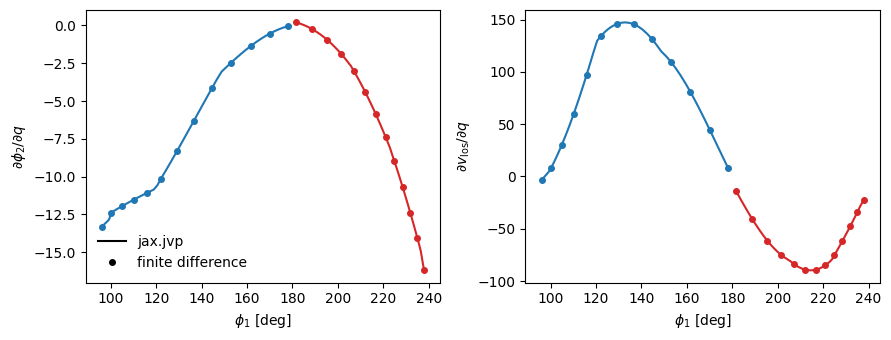

In [6]:
fd = {}
for h in [1e-6, 3e-7]:
    fd[h] = (track_and_derivative(q0 + h)[0] - track_and_derivative(q0 - h)[0]) / (
        2.0 * h
    )
    print(
        f"h = {h:.0e}: largest relative difference with jax.jvp for (phi1, phi2, vlos):",
        [
            f"{numpy.max(numpy.fabs(fd[h][i] - dtc_dq[i])) / numpy.max(numpy.fabs(dtc_dq[i])):.1e}"
            for i in range(3)
        ],
    )
nl = len(tp_lead)
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, i, label in zip(axs, [1, 2], [r"\phi_2", r"v_\mathrm{los}"]):
    for sl, c in [(slice(0, nl), "C0"), (slice(nl, None), "C3")]:
        ax.plot(tc0[0, sl], dtc_dq[i, sl], "-", color=c)
        ax.plot(tc0[0, sl][::4], fd[1e-6][i, sl][::4], "o", color=c, ms=4)
    ax.set_xlabel(r"$\phi_1$ [deg]")
    ax.set_ylabel(rf"$\partial {label} / \partial q$")
axs[0].plot([], [], "k-", label="jax.jvp")
axs[0].plot([], [], "ko", ms=4, label="finite difference")
axs[0].legend(frameon=False)
fig.tight_layout()

## Predicting the stream at another flattening

The derivatives predict the stream at a different flattening,
$q_0 + \Delta q$, to first order. There are two ways to use them: extrapolate
the track directly, $\mathrm{track}(q_0) + \Delta q\,
\mathrm{d}\,\mathrm{track}/\mathrm{d}q$, with the derivative of the track
computed above, or move every particle,
$(\vec{x},\vec{v})(q_0) + \Delta q\, \mathrm{d}(\vec{x},\vec{v})/\mathrm{d}q$,
and fit a track to the moved particles. For the second, one forward-mode pass
gives every particle's $\mathrm{d}(\vec{x},\vec{v})/\mathrm{d}q$. We sample
both tails (each with its own key) and compute the particles' derivative
with `jax.jvp`, compiled with `jax.jit`:

In [7]:
key_lead, key_trail = grandom.split(key, 2)


def particles(q):
    spdf = spray(q)
    # (R,vR,vT,z,vz,phi) of each particle, shape (6,n); leading, then trailing
    return jnp.hstack(
        [
            spdf.sample(n=1000, return_orbit=False, tail="leading", key=key_lead),
            spdf.sample(n=1000, return_orbit=False, tail="trailing", key=key_trail),
        ]
    )


particles_and_derivative = jax.jit(lambda q: jax.jvp(particles, (q,), (1.0,)))
start = time.perf_counter()
xv0, dxv_dq = particles_and_derivative(q0)
print(f"First call (compiles): {time.perf_counter() - start:.1f} s")

First call (compiles): 113.9 s


`dxv_dq` is the change of every particle's phase-space position for a unit
change in $q$, with the random numbers held fixed. It agrees with finite
differences of samples with the same key, for two step sizes:

In [8]:
for h in [1e-5, 3e-6]:
    fd_xv = (
        particles_and_derivative(q0 + h)[0] - particles_and_derivative(q0 - h)[0]
    ) / (2.0 * h)
    print(
        f"h = {h:.0e}: relative difference",
        f"{numpy.max(numpy.fabs(dxv_dq - fd_xv)) / numpy.max(numpy.fabs(dxv_dq)):.1e}",
    )

h = 1e-05: relative difference 2.9e-05


h = 3e-06: relative difference 1.8e-04


We now compare both predictions with the track of a stream that is
generated directly at $q_0 + \Delta q$ with the same random numbers. All
tracks are fit with the same compiled function. As a measure of the error,
we use the root-mean-square difference in $\phi_2$ at fixed $\phi_1$ over the
central 80% of both tails, and we compare it with the change of the track
between $q_0$ and $q_0 + \Delta q$ (the change being predicted):

dq = -0.1000: change of the track 0.637 deg; error of the prediction: extrapolated track 0.0483 deg, moved particles 0.1488 deg


dq = -0.0500: change of the track 0.307 deg; error of the prediction: extrapolated track 0.0190 deg, moved particles 0.0398 deg


dq = -0.0250: change of the track 0.149 deg; error of the prediction: extrapolated track 0.0065 deg, moved particles 0.0105 deg


dq = -0.0125: change of the track 0.075 deg; error of the prediction: extrapolated track 0.0015 deg, moved particles 0.0028 deg


dq = +0.0125: change of the track 0.074 deg; error of the prediction: extrapolated track 0.0017 deg, moved particles 0.0027 deg


dq = +0.0250: change of the track 0.146 deg; error of the prediction: extrapolated track 0.0036 deg, moved particles 0.0115 deg


dq = +0.0500: change of the track 0.288 deg; error of the prediction: extrapolated track 0.0068 deg, moved particles 0.0363 deg


dq = +0.1000: change of the track 0.556 deg; error of the prediction: extrapolated track 0.0152 deg, moved particles 0.1158 deg


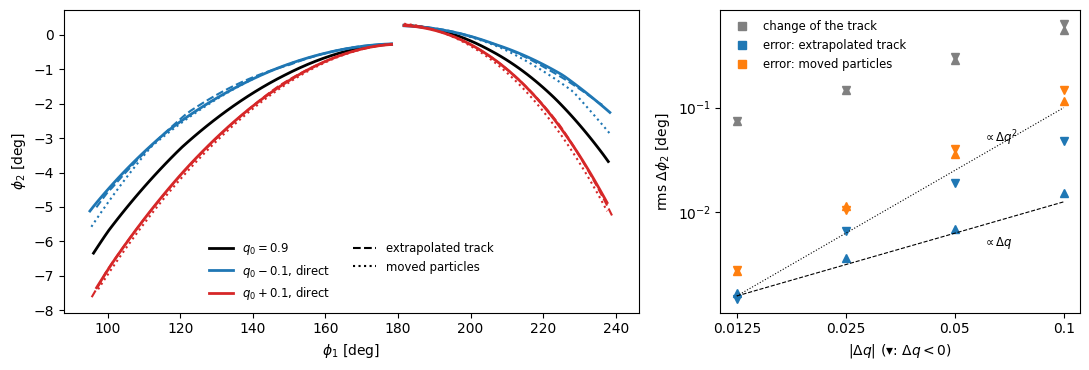

In [9]:
xv0, dxv_dq = numpy.asarray(xv0), numpy.asarray(dxv_dq)
tc0, dtc_dq = numpy.asarray(tc0), numpy.asarray(dtc_dq)


@jax.jit
def fit_coords(q, xv):
    """(phi1, phi2) of both tails at tp_lead and tp_trail, for the track fit to particles xv"""
    tr = spray(q).streamTrack(particles=xv, tail="both", custom_sky_transform=T)
    return jnp.stack(
        [
            jnp.concatenate(
                [getattr(tr.leading, c)(tp_lead), getattr(tr.trailing, c)(tp_trail)]
            )
            for c in ["phi1", "phi2"]
        ]
    )


def phi2_on_grid(tc, grids):
    # phi2 of each tail interpolated onto a fixed phi1 grid
    out = []
    for sl, g in zip([slice(0, nl), slice(nl, None)], grids):
        o = numpy.argsort(tc[0, sl])
        out.append(
            numpy.interp(g, tc[0, sl][o], tc[1, sl][o], left=numpy.nan, right=numpy.nan)
        )
    return numpy.concatenate(out)


def grids_of(tc):
    return [
        numpy.linspace(*numpy.percentile(tc[0, sl], [10.0, 90.0]), 100)
        for sl in [slice(0, nl), slice(nl, None)]
    ]


def rms(a):
    return numpy.sqrt(numpy.nanmean(a**2))


fit0 = numpy.asarray(fit_coords(q0, xv0))
grids_t, grids_p = grids_of(tc0), grids_of(fit0)
dqs = numpy.array([-0.1, -0.05, -0.025, -0.0125, 0.0125, 0.025, 0.05, 0.1])
change, err_track, err_particles, tracks = [], [], [], {}
for dq in dqs:
    # extrapolating the track
    direct_t = numpy.asarray(track_and_derivative(q0 + dq)[0])
    pred_t = tc0 + dq * dtc_dq
    # moving the particles and fitting a track to them
    direct_p = numpy.asarray(
        fit_coords(q0 + dq, numpy.asarray(particles_and_derivative(q0 + dq)[0]))
    )
    pred_p = numpy.asarray(fit_coords(q0 + dq, xv0 + dq * dxv_dq))
    change.append(rms(phi2_on_grid(direct_t, grids_t) - phi2_on_grid(tc0, grids_t)))
    err_track.append(
        rms(phi2_on_grid(pred_t, grids_t) - phi2_on_grid(direct_t, grids_t))
    )
    err_particles.append(
        rms(phi2_on_grid(pred_p, grids_p) - phi2_on_grid(direct_p, grids_p))
    )
    tracks[dq] = (direct_t, pred_t, pred_p)
    print(
        f"dq = {dq:+.4f}: change of the track {change[-1]:.3f} deg; error of the prediction: "
        f"extrapolated track {err_track[-1]:.4f} deg, moved particles {err_particles[-1]:.4f} deg"
    )
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.6, 1]}
)
for sl in [slice(0, nl), slice(nl, None)]:
    ax1.plot(tc0[0, sl], tc0[1, sl], "k-", lw=2)
    for dq, color in [(-0.1, "C0"), (0.1, "C3")]:
        direct_t, pred_t, pred_p = tracks[dq]
        ax1.plot(direct_t[0, sl], direct_t[1, sl], "-", color=color, lw=2)
        ax1.plot(pred_t[0, sl], pred_t[1, sl], "--", color=color)
        ax1.plot(pred_p[0, sl], pred_p[1, sl], ":", color=color)
ax1.plot([], [], "k-", lw=2, label=rf"$q_0={q0}$")
ax1.plot([], [], "-", color="C0", lw=2, label=r"$q_0 - 0.1$, direct")
ax1.plot([], [], "-", color="C3", lw=2, label=r"$q_0 + 0.1$, direct")
ax1.plot([], [], "k--", label="extrapolated track")
ax1.plot([], [], "k:", label="moved particles")
ax1.set_xlabel(r"$\phi_1$ [deg]")
ax1.set_ylabel(r"$\phi_2$ [deg]")
ax1.legend(frameon=False, fontsize="small", loc="lower center", ncol=2)
adq = numpy.fabs(dqs)
for sign, mk in [(-1, "v"), (1, "^")]:
    sel = numpy.sign(dqs) == sign
    ax2.loglog(adq[sel], numpy.array(change)[sel], mk, color="0.5")
    ax2.loglog(adq[sel], numpy.array(err_track)[sel], mk, color="C0")
    ax2.loglog(adq[sel], numpy.array(err_particles)[sel], mk, color="C1")
xx = numpy.array([0.0125, 0.1])
e0 = numpy.mean(numpy.array(err_track)[adq == 0.0125])
ax2.loglog(xx, e0 * (xx / 0.0125) ** 2, "k:", lw=0.8)
ax2.loglog(xx, e0 * (xx / 0.0125), "k--", lw=0.8)
ax2.text(0.06, e0 * 30, r"$\propto \Delta q^2$", fontsize="small")
ax2.text(0.06, e0 * 3.0, r"$\propto \Delta q$", fontsize="small")
ax2.plot([], [], "s", color="0.5", label="change of the track")
ax2.plot([], [], "s", color="C0", label="error: extrapolated track")
ax2.plot([], [], "s", color="C1", label="error: moved particles")
ax2.set_xticks([0.0125, 0.025, 0.05, 0.1], ["0.0125", "0.025", "0.05", "0.1"])
ax2.minorticks_off()
ax2.set_xlabel(r"$|\Delta q|$ ($\blacktriangledown$: $\Delta q<0$)")
ax2.set_ylabel(r"rms $\Delta\phi_2$ [deg]")
ax2.legend(frameon=False, fontsize="small")
fig.tight_layout()

Both predictions capture most of the change of the track, but extrapolating
the track is up to eight times more accurate than moving the particles: the
error of the extrapolated track is 2% to 8% of the change. For $\Delta q < 0$
this error grows nearly as $\Delta q^2$, as expected for a first-order
prediction, but for $\Delta q > 0$ it grows nearly linearly. Part of the
error therefore comes from the discrete choices of the track fit, which the
extrapolation holds fixed at $q_0$ while the fit of the directly generated
stream makes them anew. The present position of each
particle depends nonlinearly on $q$, because small changes in its orbital
frequencies build up into large shifts along the stream over the time since
it was stripped. The track averages over many particles and depends more
nearly linearly on $q$. Moving the particles also lets the track fit make its
discrete choices again on a set of particles that differs from the directly
generated one.

For fitting a stream model to data, smooth statistics of the particles are
also well-behaved. For example, the derivative of the mean of $z^2$ over the
particles follows from the particles' derivative,
$\mathrm{d}\langle z^2\rangle/\mathrm{d}q = \langle 2 z\, \mathrm{d}z/\mathrm{d}q\rangle$,
and agrees with a finite difference:

In [10]:
h = 1e-5
print(
    numpy.mean(2.0 * xv0[3] * dxv_dq[3]),
    (
        jnp.mean(particles_and_derivative(q0 + h)[0][3] ** 2)
        - jnp.mean(particles_and_derivative(q0 - h)[0][3] ** 2)
    )
    / (2.0 * h),
)

0.136682198341256 0.1366819852910428


Reverse mode (`jax.grad`, `jax.vjp`) works as well and is the efficient
choice for the derivative of a scalar, such as a likelihood, with respect to
many parameters.

## Notes

* `chen24spraydf` works in the same way.
* The same computation runs with PyTorch, with a PyTorch key and potential
  parameters given as tensors; the particles are integrated with torchode.
  In eager mode on a CPU this is slow (one to two minutes for 500
  particles); it can be compiled with `torch.compile` or run on a GPU.
* Each particle's orbit is one more orbit in a batch, so on a GPU large
  streams cost little more than small ones.